In [31]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path 
import numpy as np


name = "DST_BIL54.csv"
df = pd.read_csv(name)

In [32]:
# "Total" angives i millioner 
df["total"] = df["total"]/(10**6)
# Object to datetime 
df["time"] = pd.to_datetime(df["time"])

In [33]:
# Creating a "year" column with decimal values for months
df["year"] = df["time"].dt.year + (df["time"].dt.month - 1) / 12

Vi koncenterer os herfra om variablerne "total" og "year":

* y:  total car registrations
* x:  datetime, year and month 

In [34]:
x = df["year"]
y = df["total"]

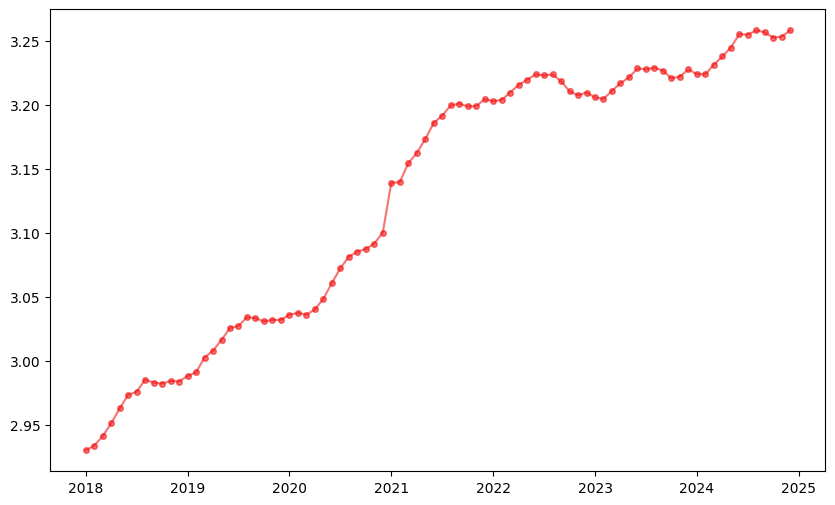

In [35]:
plt.figure(figsize=(10,6))
plt.plot(x, y, marker="o", linestyle="-", color="lightgrey", alpha = 0.4, markersize = 4)
plt.plot(x, y, marker="o", linestyle="-", color="red", alpha = 0.5, markersize = 4)


In [36]:
cut = "2024-01-01"
cut = pd.to_datetime(cut)


df_train = df[df["time"] < cut]
df_test  = df[df["time"] >= cut]


In [37]:
x_train = df_train["year"]
y_train = df_train["total"]
x_test = df_test["year"]
y_test = df_test["total"]

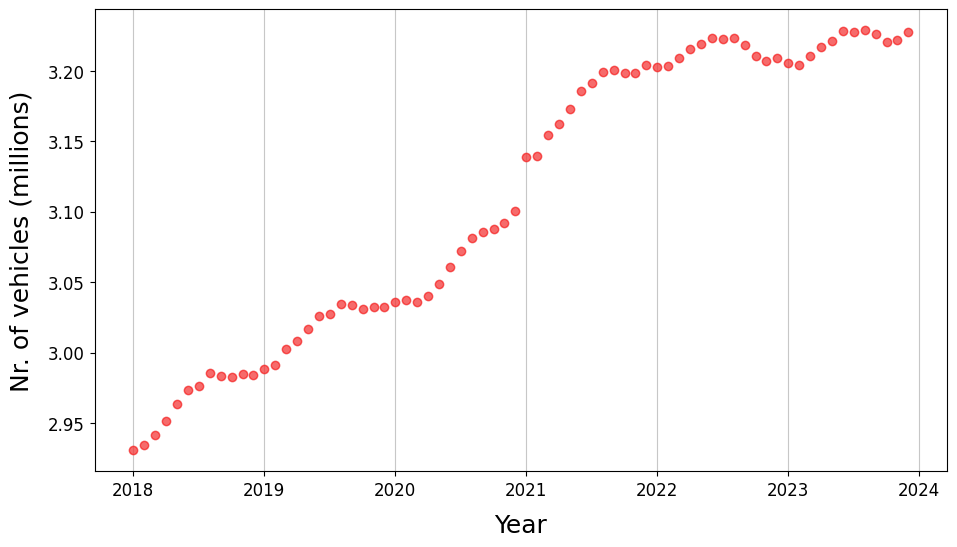

In [38]:
plt.figure(figsize=(11,6))
plt.plot(x_train, y_train, marker="o", linestyle="", label="Train", color = "lightgrey", alpha = 0.4)
plt.plot(x_train, y_train, marker="o", linestyle="", label="Train", color = "red", alpha = 0.55)
plt.grid(axis = "x", alpha = 0.7)
plt.xlabel("Year", fontsize = 18, labelpad=10)
plt.ylabel("Nr. of vehicles (millions)", fontsize = 18, labelpad=10)
plt.xticks(fontsize = 12)
plt.yticks(fontsize = 12)
plt.show()


GLM:

$Y_t = \theta_1 + \theta_2 \cdot x_t + \epsilon_t $

In [39]:
# Design matrix for training data
A = np.column_stack([np.ones(len(x_train)), x_train])

In [40]:
print("Determinant:",np.linalg.det(A.T @ A))
print("Rang: ", np.linalg.matrix_rank(A))

Determinant: 15549.000004242993
Rang:  2


In [41]:
c = np.linalg.solve(A.T@A, A.T@y_train)
print(c)

[-1.10355428e+02  5.61445562e-02]


In [42]:
c1 = np.linalg.lstsq(A, y_train, rcond=None)[0]   # mest stabilt
c2 = np.linalg.pinv(A) @ y_train                  # bruger Moore–Penrose pseudoinvers
c1, c2

(array([-1.10355428e+02,  5.61445562e-02]),
 array([-1.10355428e+02,  5.61445562e-02]))

In [43]:
print(c[0],c[1])

-110.35542809545484 0.056144556225888084


In [44]:
y_pred = c[0] + c[1] * x_test
y_train_pred = c[0] + c[1] * x_train

In [45]:
y_pred.shape, y_test.shape

((12,), (12,))

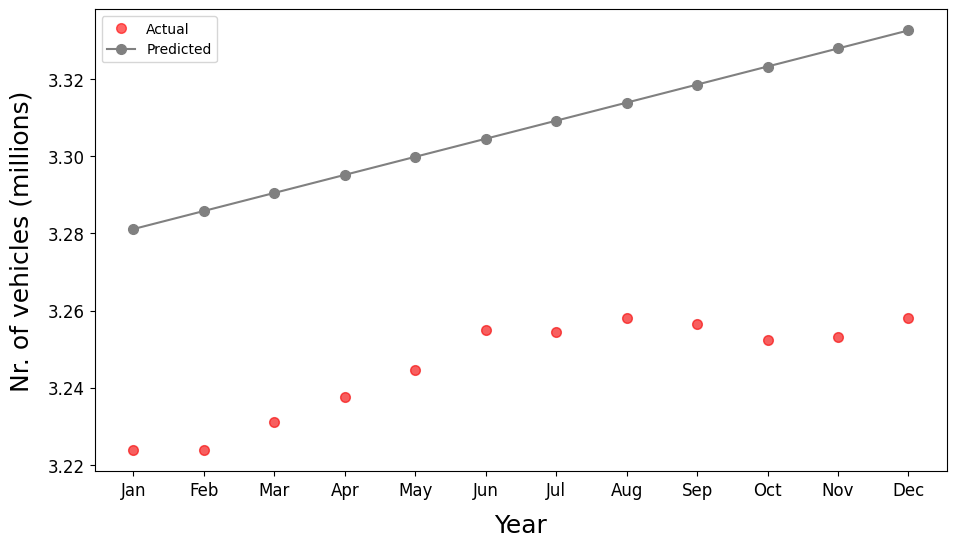

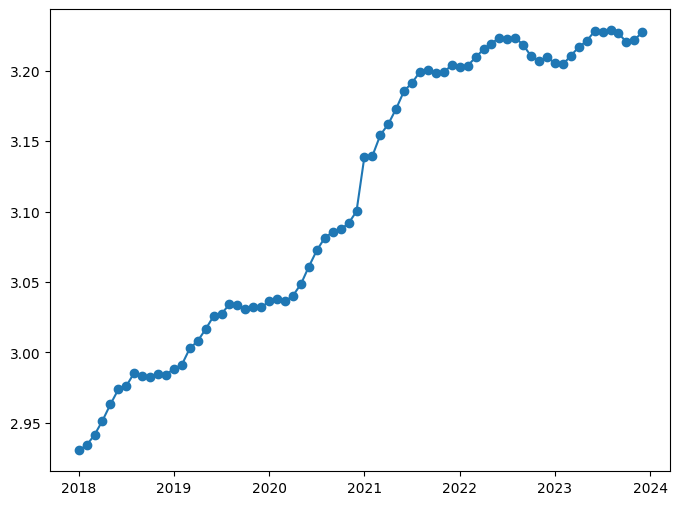

In [46]:
x_ind = np.arange(len(y_test)) # 0,1,2,...,11
plt.figure(figsize=(11,6))
plt.plot(x_ind, y_test, marker="o", linestyle="", color = "lightgrey", alpha = 0.4, markersize = 7)
plt.plot(x_ind, y_test, marker="o", linestyle="", color = "red", alpha = 0.6, label="Actual", markersize = 7)
plt.plot(x_ind, y_pred, label="Predicted", marker="o", linestyle="-", color = "grey", markersize = 7)
plt.xlabel("Year", fontsize = 18, labelpad=10)
plt.ylabel("Nr. of vehicles (millions)", fontsize = 18, labelpad=10)
plt.xticks(
    ticks = range(len(y_test)),
    labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
              "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"],
    fontsize = 12
)

plt.yticks(fontsize = 12)

plt.legend()
plt.show()

plt.figure(figsize=(8,6))
plt.plot(x_train, y_train, marker="o", linestyle="-", label="Train")

## Task 4

In [47]:
df_train.head

<bound method NDFrame.head of          time     total  gasoline   diesel  fgas  ngas  electricity  \
0  2018-01-01  2.930483   1781826  1136656    12   256         9304   
1  2018-02-01  2.934044   1783338  1138414    12   255         9343   
2  2018-03-01  2.941422   1787219  1141576    12   257         9399   
3  2018-04-01  2.951498   1793554  1144846    12   257         9548   
4  2018-05-01  2.963093   1799795  1149840    12   256         9665   
..        ...       ...       ...      ...   ...   ...          ...   
67 2023-08-01  3.228835   1851651  1091900    16   552       166046   
68 2023-09-01  3.226588   1845911  1084498    16   550       175592   
69 2023-10-01  3.220559   1838787  1075629    16   533       184125   
70 2023-11-01  3.221920   1835019  1068514    16   533       194948   
71 2023-12-01  3.227541   1831941  1062385    16   533       207888   

    petroleum  hydrogen  methanol  ethanol  pluginhybrid  otherfuels  \
0           0        81         0        0   

In [48]:
N = len(x_train)
time_t = np.arange(0,N)

#4.1 find covariance variance matrix 
lambda_init = 0.9

lambda_weights = lambda_init ** np.arange(N-1, -1, -1)
cov_var_matrix_WLS = np.diag(1/lambda_weights)  #(3.98) in TSA book
cov_var_matrix_OLS = np.identity(N) #3.2.1.3 Unweighted LS estimates (TSA book)

print(cov_var_matrix_WLS[60][60])
print(cov_var_matrix_OLS[60][60])

3.186635545324934
1.0


Text(0, 0.5, 'weight (lambda)')

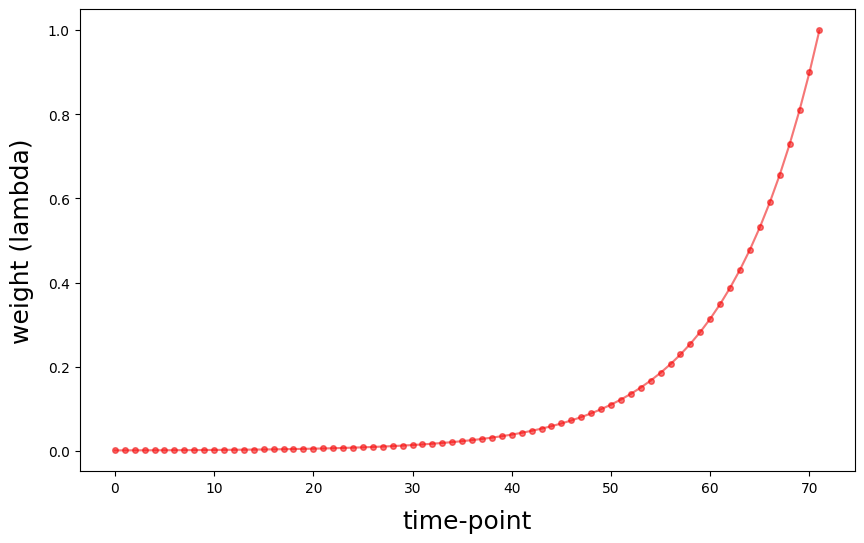

In [49]:
#4.2 plot weights as a function of timepoints for 

plt.figure(figsize=(10,6))
plt.plot(time_t, lambda_weights, marker="o", linestyle="-", color="lightgrey", alpha = 0.4, markersize = 4)
plt.plot(time_t, lambda_weights, marker="o", linestyle="-", color="red", alpha = 0.5, markersize = 4)
plt.xlabel("time-point", fontsize = 18, labelpad=10)
plt.ylabel("weight (lambda)", fontsize = 18, labelpad=10)

In [50]:
# 4.3 sum weights (lambda) and OLS
print("sum of WLS weights", lambda_weights.sum())

print("\nsum of OLS weights", N)

sum of WLS weights 9.994924712139436

sum of OLS weights 72


In [51]:
#4.4 estimate unknown params with weigts
    #eq (3.99)in TSA book
xtrains= np.column_stack([np.ones(len(x_train)), x_train])
ytrains= y_train.to_numpy().reshape(-1, 1)   

cov_var_matrix_WLS_reciprocal = np.diag(lambda_weights)

F_N_WLS = xtrains.T @ cov_var_matrix_WLS_reciprocal @ xtrains

h_N_WLS =  xtrains.T @  cov_var_matrix_WLS_reciprocal @ ytrains

thetas = np.linalg.inv(F_N_WLS) @  h_N_WLS

print("theta 1 (intercept): ", thetas[0],"\ntheta 2 (slope): ", thetas[1])

theta 1 (intercept):  [-52.48286172] 
theta 2 (slope):  [0.0275299]


In [52]:
x_test

72    2024.000000
73    2024.083333
74    2024.166667
75    2024.250000
76    2024.333333
77    2024.416667
78    2024.500000
79    2024.583333
80    2024.666667
81    2024.750000
82    2024.833333
83    2024.916667
Name: year, dtype: float64

In [53]:
thetas[0] + thetas[1] * x_test

72    3.237659
73    3.239953
74    3.242247
75    3.244541
76    3.246836
77    3.249130
78    3.251424
79    3.253718
80    3.256012
81    3.258306
82    3.260601
83    3.262895
Name: year, dtype: float64

In [54]:
xtrains= np.column_stack([np.ones(len(x_train)), x_train])
ytrains= y_train.to_numpy().reshape(-1, 1)   

def predict_12_WLS(lambda_init_value):
    lambda_weights = lambda_init_value ** np.arange(N-1, -1, -1)
    cov_var_matrix_WLS_reciprocal = np.diag(lambda_weights)
    F_N_WLS = xtrains.T @ cov_var_matrix_WLS_reciprocal @ xtrains
    h_N_WLS =  xtrains.T @  cov_var_matrix_WLS_reciprocal @ ytrains
    thetas = np.linalg.inv(F_N_WLS) @  h_N_WLS

    print("lambda ", lambda_init_value,"\ntheta 1 (intercept): ", thetas[0],"theta 2 (slope): ", thetas[1])


#HAve function return as list so it can be plotted later
    return thetas[0] + thetas[1] * x_test

lambda  0.9 
theta 1 (intercept):  [-52.48286172] theta 2 (slope):  [0.0275299]


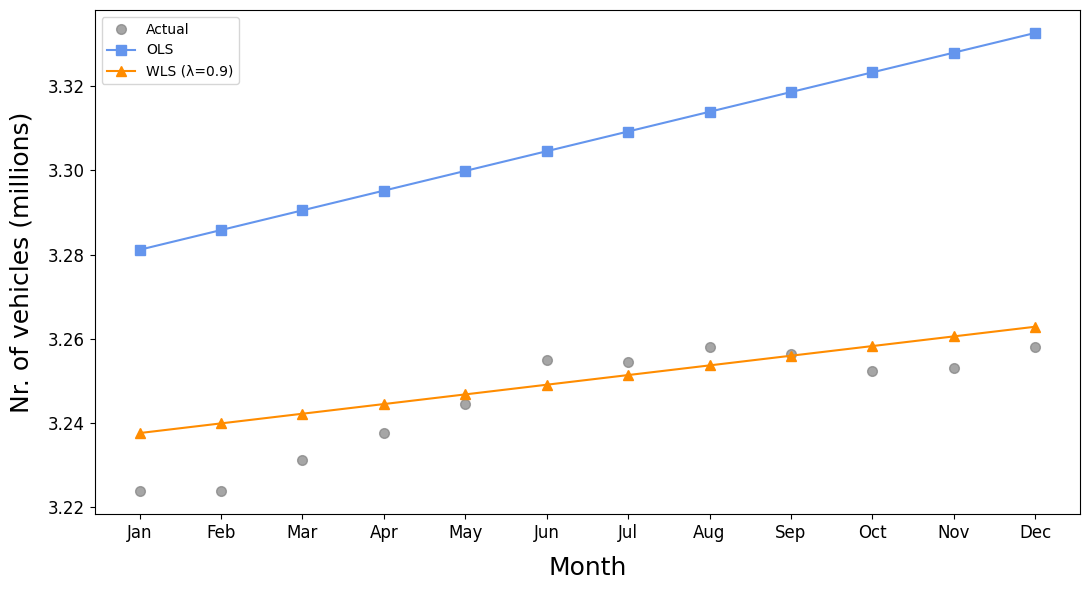

In [69]:
#4.5 predict 12 time-steps ahead and plot agains OLS preds
y_pred_wls = predict_12_WLS(0.9)

x_ind = np.arange(len(y_test))
y_pred_ols = y_pred
plt.figure(figsize=(11,6))
plt.plot(
    x_ind, y_test,
    marker="o",
    linestyle="",
    color="grey",
    alpha=0.7,
    label="Actual",
    markersize=7
)
plt.plot(
    x_ind, y_pred_ols,
    marker="s",
    linestyle="-",
    color="cornflowerblue",
    label="OLS",
    markersize=7
)
plt.plot(
    x_ind, y_pred_wls,
    marker="^",
    linestyle="-",
    color="darkorange",
    label="WLS (λ=0.9)",
    markersize=7
)

plt.xlabel("Month", fontsize=18, labelpad=10)
plt.ylabel("Nr. of vehicles (millions)", fontsize=18, labelpad=10)

plt.xticks(
    ticks=range(len(y_test)),
    labels=["Jan", "Feb", "Mar", "Apr", "May", "Jun",
            "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"],
    fontsize=12
)

plt.yticks(fontsize=12)

plt.legend()
plt.tight_layout()
plt.show()

In [58]:
#4.6 repeat for λ = 0.99, λ = 0.8, λ = 0.7 and λ = 0.6.
lambda_initialization_list = [0.99, 0.8, 0.7, 0.6]
boxto = []
for inits in lambda_initialization_list:
    boxto.append(predict_12_WLS(inits))

print(boxto)




lambda  0.99 
theta 1 (intercept):  [-107.09818742] theta 2 (slope):  [0.05453297]
lambda  0.8 
theta 1 (intercept):  [-21.52797312] theta 2 (slope):  [0.01223115]
lambda  0.7 
theta 1 (intercept):  [-15.73997849] theta 2 (slope):  [0.00937098]
lambda  0.6 
theta 1 (intercept):  [-11.32407116] theta 2 (slope):  [0.00718895]
[72    3.276551
73    3.281096
74    3.285640
75    3.290185
76    3.294729
77    3.299274
78    3.303818
79    3.308362
80    3.312907
81    3.317451
82    3.321996
83    3.326540
Name: year, dtype: float64, 72    3.227869
73    3.228888
74    3.229907
75    3.230926
76    3.231946
77    3.232965
78    3.233984
79    3.235003
80    3.236023
81    3.237042
82    3.238061
83    3.239080
Name: year, dtype: float64, 72    3.226889
73    3.227670
74    3.228451
75    3.229232
76    3.230013
77    3.230793
78    3.231574
79    3.232355
80    3.233136
81    3.233917
82    3.234698
83    3.235479
Name: year, dtype: float64, 72    3.226355
73    3.226954
74    3.227554
75  